# StackOverflow Raw Data Evaluation

This notebook evaluates the raw `stackoverflow_full_data.csv` to understand its quality, distribution, and potential issues before further processing.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [14]:
DATA_PATH = '../data/stackoverflow/stackoverflow_full_data.csv'

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # Try alternative path
    df = pd.read_csv('DataMining/data/stackoverflow/stackoverflow_full_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows in Raw File: {len(df)}")
df.head()

Dataset Shape: (7672347, 8)
Total Rows in Raw File: 7672347


,id,creation_date,title,tags,view_count,score,answer_count,comment_count
0,20869072,2014-01-01 13:23:42.980000+00:00,Laravel Schema onDelete set null,php|laravel|laravel-migrations,125184,157,8,0
1,20866033,2014-01-01 06:07:34.750000+00:00,Starting emulator for AVD avd PANIC: Could not...,android|eclipse|adt,7939,6,7,0
2,20876138,2014-01-02 04:02:02.927000+00:00,Close the app when back is pressed,android|android-layout|android-fragments|andro...,268,2,8,0
3,20870202,2014-01-01 15:37:09.773000+00:00,How to add Activity to manifest.xml in right way?,android|android-activity|android-manifest,70943,26,7,0
4,20872344,2014-01-01 19:26:41.197000+00:00,Why does simple website crash on mobile (iOS S...,ios|google-chrome|memory|memory-leaks|crash,35371,17,8,0


## 2. Basic Statistics & Duplicates

In [4]:
# Check for duplicates
if 'id' in df.columns:
    dup_count = df.duplicated(subset=['id']).sum()
    print(f"Duplicate IDs: {dup_count} ({(dup_count/len(df))*100:.2f}%)")
else:
    dup_count = df.duplicated().sum()
    print(f"Full Row Duplicates: {dup_count} ({(dup_count/len(df))*100:.2f}%)")

# General Info
df.info()

Duplicate IDs: 0 (0.00%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672347 entries, 0 to 7672346
Data columns (total 8 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   id             int64 
 1   creation_date  object
 2   title          object
 3   tags           object
 4   view_count     int64 
 5   score          int64 
 6   answer_count   int64 
 7   comment_count  int64 
dtypes: int64(5), object(3)
memory usage: 468.3+ MB


## 3. Missing Values Analysis

      Missing Count  Percentage
tags              4    0.000052


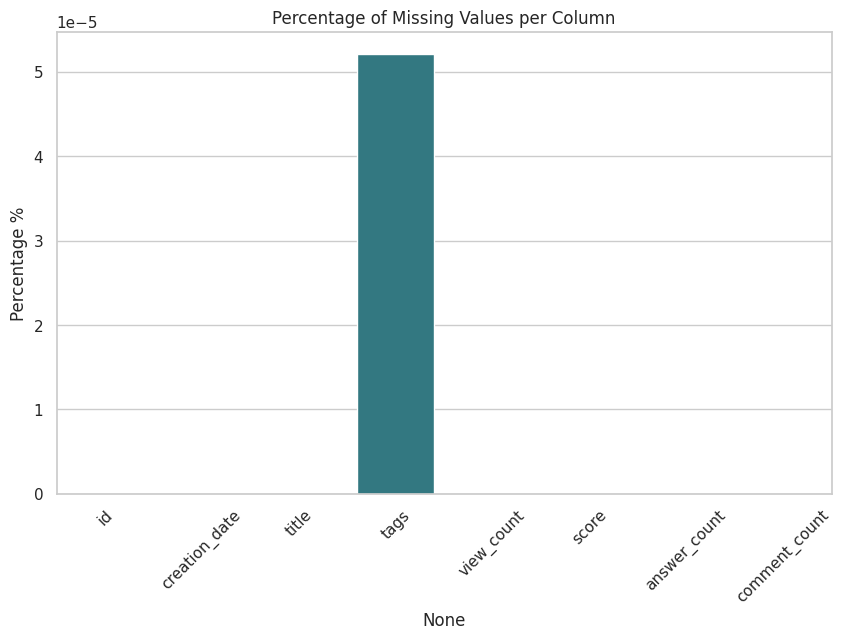

In [5]:
try:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_df[missing_df['Missing Count'] > 0])

    # Visualize Missing Values
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_pct.index, y=missing_pct.values, hue=missing_pct.index, palette='viridis', legend=False)
    plt.title('Percentage of Missing Values per Column')
    plt.ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.show()
except Exception as e:
    print(f"Plotting error: {e}")

## 4. Temporal Analysis

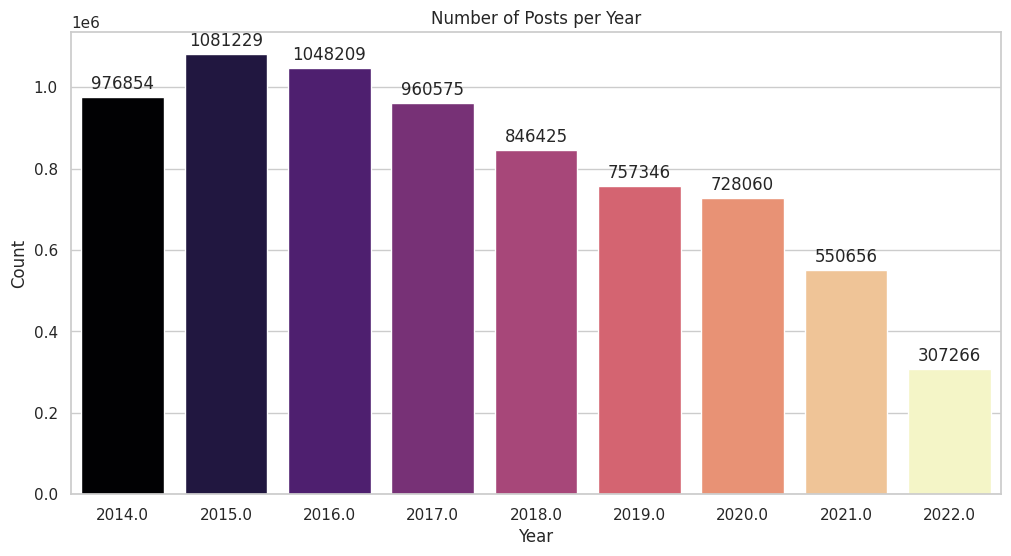

In [12]:
try:
    # Convert creation_date to datetime
    if 'creation_date' in df.columns:
        # Standardize datetime parsing
        df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce', utc=True)
        
        # Extract Year
        df['year'] = df['creation_date'].dt.year
        
        # Count posts per year
        year_counts = df['year'].value_counts().sort_index()
        
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x=year_counts.index, y=year_counts.values, hue=year_counts.index, palette='magma', legend=False)
        plt.title('Number of Posts per Year')
        plt.xlabel('Year')
        plt.ylabel('Count')

        # Add value labels on top of bars (hiển thị số dòng)
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=3)

        plt.show()
except Exception as e:
    print(f"Temporal plotting error: {e}")

## 5. Numerical Distributions

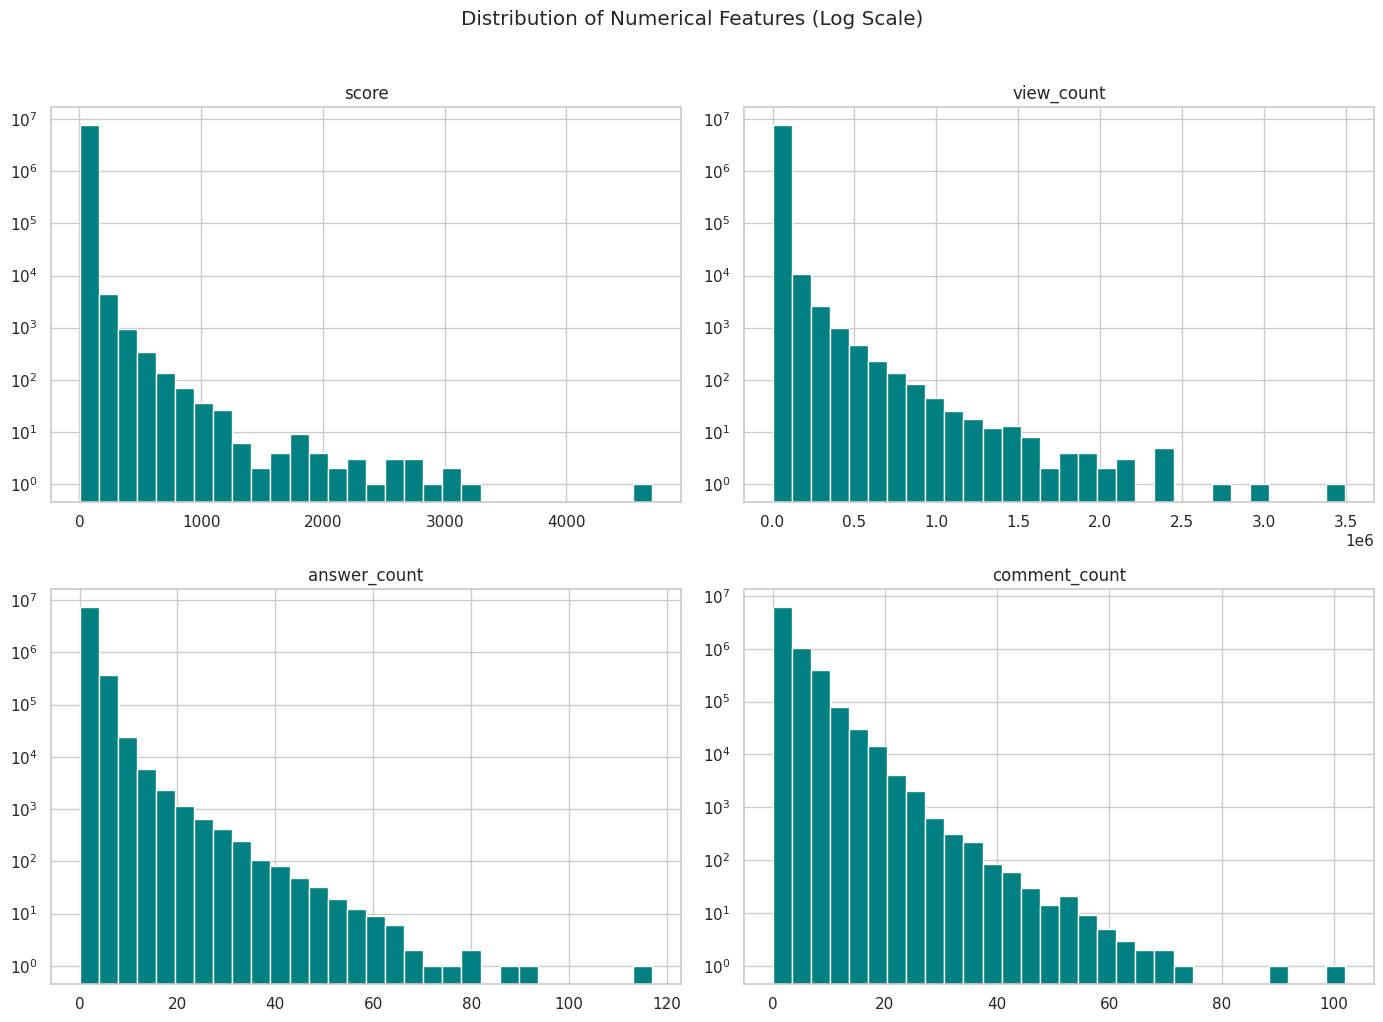

In [ ]:
try:
    num_cols = ['score', 'view_count', 'answer_count', 'comment_count']
    existing_cols = [c for c in num_cols if c in df.columns]

    if existing_cols:
        # Use pandas plotting backend which handles large data and log scales robustly
        df[existing_cols].hist(bins=30, figsize=(14, 10), log=True, color='teal')
        plt.suptitle('Distribution of Numerical Features (Log Scale)', y=1.02)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Numerical plotting error: {e}")

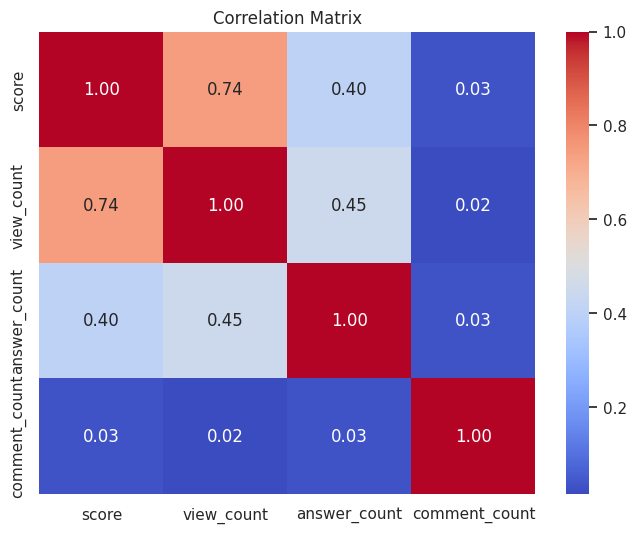

In [ ]:
try:
    # Correlation Matrix
    if existing_cols:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[existing_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Matrix')
        plt.show()
except Exception as e:
    print(f"Correlation error: {e}")

## 6. Tags Analysis

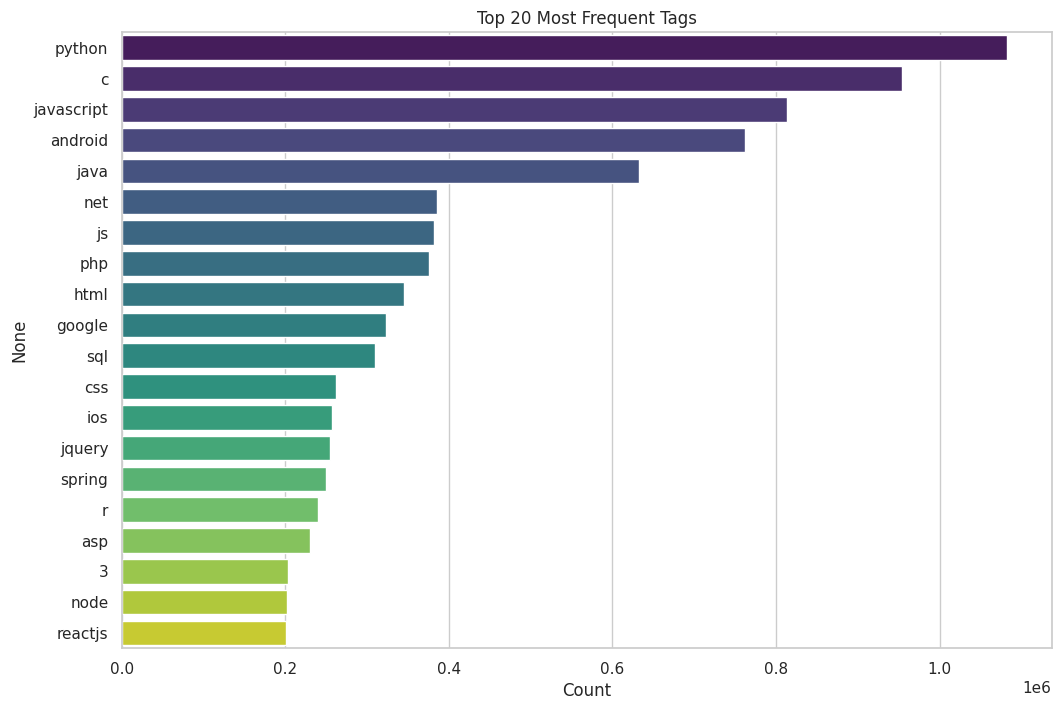

In [ ]:
try:
    if 'tags' in df.columns:
        all_tags = df['tags'].dropna().astype(str).str.replace(r'[^\w\s]', ' ', regex=True).str.split(expand=True).stack()
        top_tags = all_tags.value_counts().head(20)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(y=top_tags.index, x=top_tags.values, hue=top_tags.index, palette='viridis', legend=False)
        plt.title('Top 20 Most Frequent Tags')
        plt.xlabel('Count')
        plt.show()
except Exception as e:
    print(f"Tag plotting error: {e}")

## 7. Title Length Analysis

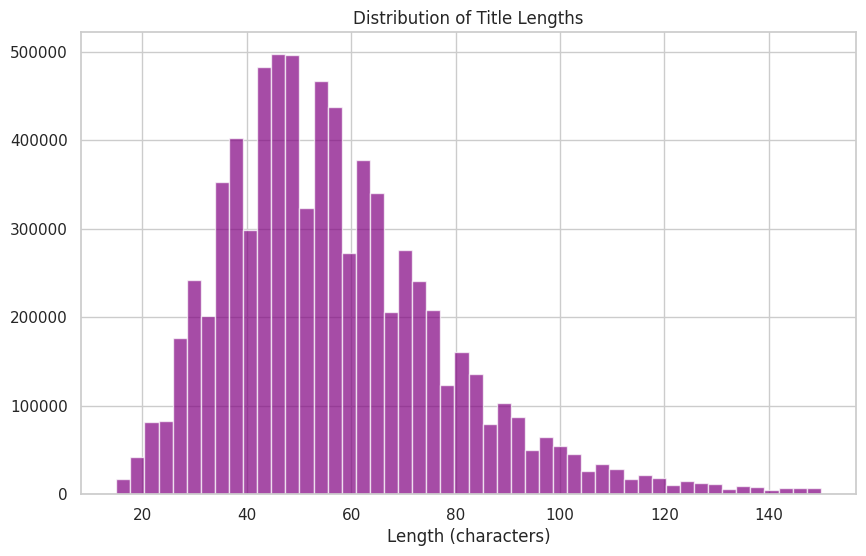

In [ ]:
try:
    if 'title' in df.columns:
        df['title_len'] = df['title'].astype(str).apply(len)

        plt.figure(figsize=(10, 6))
        plt.hist(df['title_len'], bins=50, color='purple', alpha=0.7)
        plt.title('Distribution of Title Lengths')
        plt.xlabel('Length (characters)')
        plt.grid(True)
        plt.show()
except Exception as e:
    print(f"Title length plotting error: {e}")